In [190]:
import pandas as pd
import numpy as np

In [191]:
from pathlib import Path
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR = BASE_DIR / "reports"/"D4"
nav_df = pd.read_csv(PROCESSED_DIR / "nav_history_clean.csv")

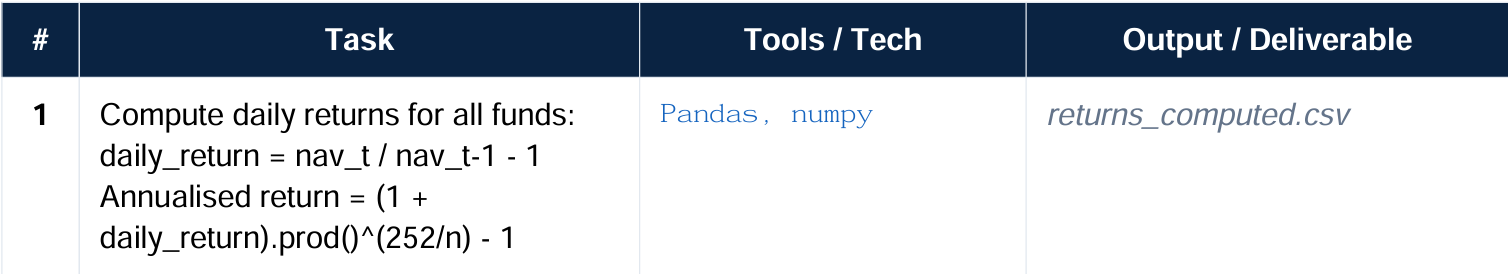

In [192]:
nav_df.columns

Index(['date', 'amfi_code', 'nav'], dtype='object')

In [193]:
daily_returns = [None]
for i in range(1, len(nav_df)):
    ret = (nav_df["nav"].iloc[i] / nav_df["nav"].iloc[i-1]) - 1
    daily_returns.append(ret)
nav_df["daily_return"] = daily_returns

In [194]:
nav_df['daily_return']=nav_df['daily_return'].fillna(0)

In [195]:
nav_df["annual_return"] = (nav_df.groupby("amfi_code")["daily_return"].transform(lambda x:(1 + x.fillna(0)).prod()** (252 / len(x))- 1))

In [196]:
nav_df.isnull().sum()

date             0
amfi_code        0
nav              0
daily_return     0
annual_return    0
dtype: int64

In [197]:
nav_df.to_csv(REPORT_DIR/'returns_computed.csv')

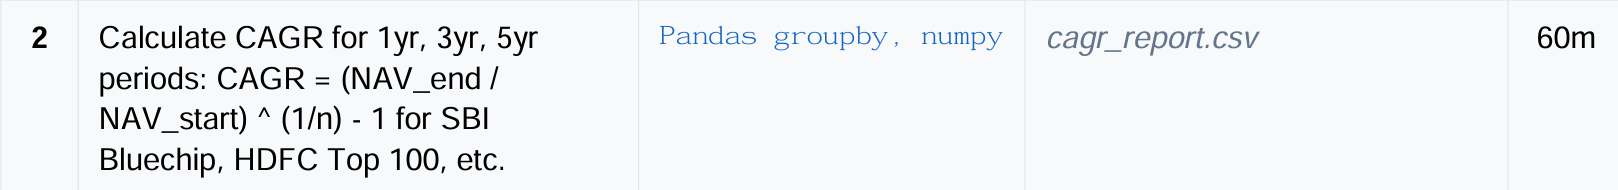

In [198]:
fund_df = pd.read_csv(PROCESSED_DIR / "fund_master_clean.csv")

In [199]:
df = nav_df.merge(fund_df[["amfi_code","scheme_name"]],on="amfi_code")

In [200]:
df['date']=pd.to_datetime(df['date'])

In [201]:
df

,date,amfi_code,nav,daily_return,annual_return,scheme_name
0,2022-01-03,100016.0,520.4608,0.000000,0.018109,HDFC Top 100 Fund - Regular Plan - Growth
1,2022-01-04,100016.0,515.0971,-0.010306,0.018109,HDFC Top 100 Fund - Regular Plan - Growth
2,2022-01-05,100016.0,521.7239,0.012865,0.018109,HDFC Top 100 Fund - Regular Plan - Growth
3,2022-01-06,100016.0,515.7880,-0.011377,0.018109,HDFC Top 100 Fund - Regular Plan - Growth
4,2022-01-07,100016.0,515.1639,-0.001210,0.018109,HDFC Top 100 Fund - Regular Plan - Growth
...,...,...,...,...,...,...
64315,2026-05-25,149324.0,292.4810,0.012106,0.020767,DSP Small Cap Fund - Regular - Growth
64316,2026-05-26,149324.0,291.2707,-0.004138,0.020767,DSP Small Cap Fund - Regular - Growth
64317,2026-05-27,149324.0,288.8007,-0.008480,0.020767,DSP Small Cap Fund - Regular - Growth
64318,2026-05-28,149324.0,280.6873,-0.028093,0.020767,DSP Small Cap Fund - Regular - Growth


In [202]:
result = []
for code in df["amfi_code"].unique():
    fund = df[df["amfi_code"] == code].sort_values("date")
    start_nav = fund["nav"].iloc[0]
    end_nav = fund["nav"].iloc[-1]
    cagr_1y = ((end_nav / start_nav) ** (1/1) - 1) * 100
    cagr_3y = ((end_nav / start_nav) ** (1/3) - 1) * 100
    cagr_5y = ((end_nav / start_nav) ** (1/5) - 1) * 100
    result.append([code,fund["scheme_name"].iloc[0],round(cagr_1y, 2),round(cagr_3y, 2),round(cagr_5y, 2)])

In [203]:
cagr_df = pd.DataFrame(result,columns=["amfi_code","scheme_name","1Y_CAGR","3Y_CAGR","5Y_CAGR"])
cagr_df.head()

,amfi_code,scheme_name,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016.0,HDFC Top 100 Fund - Regular Plan - Growth,12.13,3.89,2.32
1,100025.0,HDFC Short Term Debt Fund - Regular - Growth,21.16,6.61,3.91
2,100033.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,218.51,47.13,26.07
3,101206.0,ABSL Frontline Equity Fund - Regular - Growth,153.46,36.34,20.44
4,101207.0,ABSL Small Cap Fund - Regular - Growth,39.95,11.86,6.95


In [204]:
cagr_df.to_csv(REPORT_DIR/'cagr_report.csv')

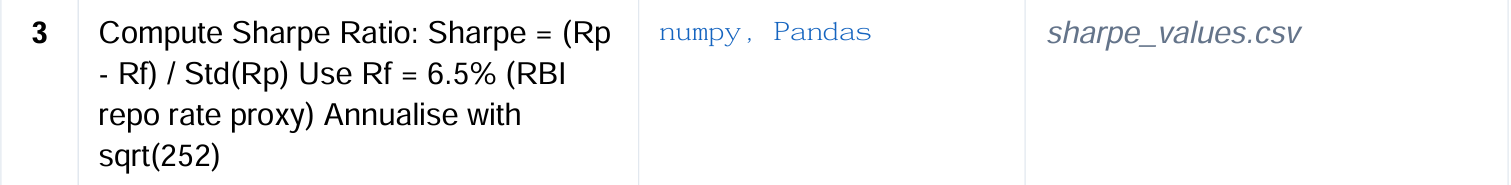

In [205]:
nav_df["daily_return"] = (nav_df.groupby("amfi_code")["nav"].pct_change())
risk_free_rate = 0.065
result = []
for code in nav_df["amfi_code"].unique():
    annual_return = ((1 + fund["daily_return"].fillna(0)).prod()** (252 / len(fund))- 1)
    annual_risk = (fund["daily_return"].std()* np.sqrt(252))
    sharpe = (annual_return - risk_free_rate)/ annual_risk
    result.append([code,round(sharpe, 2)])

In [206]:
sharpe_df = pd.DataFrame(result,columns=["amfi_code","sharpe_ratio"])

In [207]:
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016.0,-0.13
1,100025.0,-0.13
2,100033.0,-0.13
3,101206.0,-0.13
4,101207.0,-0.13


In [208]:
sharpe_df.to_csv(REPORT_DIR/ "sharpe_values.csv")

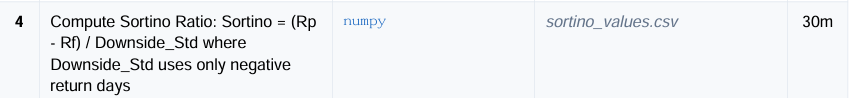

In [209]:
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()
rf = 0.065

In [210]:
result = []
for code in nav_df["amfi_code"].unique():
    fund = nav_df[nav_df["amfi_code"] == code]
    annual_return = ((1 + fund["daily_return"].fillna(0)).prod()** (252 / len(fund))- 1)
    downside = fund[fund["daily_return"] < 0]["daily_return"]
    downside_std = (downside.std()* np.sqrt(252))
    sortino = (annual_return - rf) / downside_std
    result.append([code,round(sortino, 2)])

In [211]:
sortino_df = pd.DataFrame(result,columns=["amfi_code", "sortino_ratio"])

In [212]:
sortino_df.to_csv(REPORT_DIR/ "sortino_values.csv")

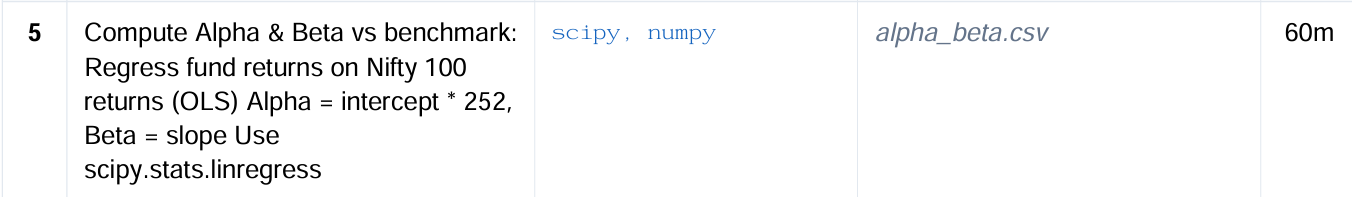

In [213]:
benchmark_df = pd.read_csv(PROCESSED_DIR / "benchmark_indices_clean.csv")

In [214]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])
benchmark_df = benchmark_df.sort_values("date")
benchmark_df["benchmark_return"] = (benchmark_df["close_value"].pct_change())

In [215]:
from scipy.stats import linregress

In [216]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [217]:
benchmark_df=benchmark_df.fillna(0)

In [218]:
benchmark_df = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

benchmark_df = benchmark_df.sort_values("date")

benchmark_df["benchmark_return"] = (
    benchmark_df["close_value"]
    .pct_change()
)

In [219]:
result = []
for code in nav_df["amfi_code"].unique():
    fund = nav_df[nav_df["amfi_code"] == code]
    merged = pd.merge(fund,benchmark_df,on="date")
    merged = merged.dropna(subset=["benchmark_return", "daily_return"])
    if len(merged) < 2:
        continue
    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )
    alpha = intercept * 252
    beta = slope
    result.append([code,round(alpha, 4),round(beta, 4)])
alpha_beta_df = pd.DataFrame(result,columns=["amfi_code", "alpha", "beta"])

In [220]:
alpha_beta_df = pd.DataFrame(result,columns=["amfi_code","alpha","beta"])

In [221]:
benchmark_df.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [222]:
benchmark_df["index_name"].unique()

array(['NIFTY50'], dtype=object)

In [223]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016.0,0.0362,-0.0259
1,100025.0,0.0432,-0.0162
2,100033.0,0.2723,-0.0112
3,101206.0,0.2139,0.0338
4,101207.0,0.1082,-0.0599


In [224]:
alpha_beta_df.to_csv(REPORT_DIR/ "alpha_beta.csv")

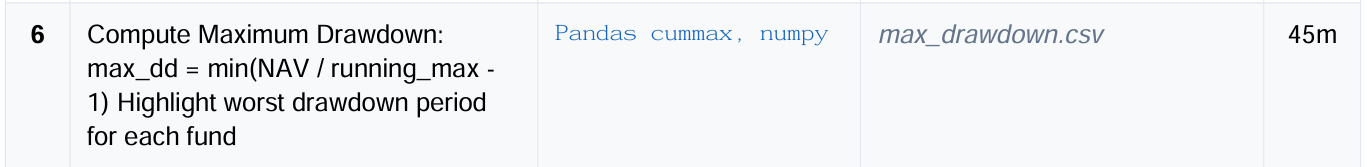

In [225]:
result = []
for code in nav_df["amfi_code"].unique():
    fund = nav_df[nav_df["amfi_code"] == code].copy()
    fund = fund.sort_values("date")
    fund["running_max"] = (fund["nav"].cummax())
    fund["drawdown"] = (fund["nav"]/fund["running_max"]- 1)
    max_dd = fund["drawdown"].min()
    result.append([code,round(max_dd * 100, 2)])
max_dd_df = pd.DataFrame(result,columns=["amfi_code","max_drawdown_pct"])

In [226]:
max_dd_df.to_csv(REPORT_DIR/ "max_drawdown.csv")

In [227]:
max_dd_df.head()

,amfi_code,max_drawdown_pct
0,100016.0,-24.73
1,100025.0,-4.31
2,100033.0,-16.22
3,101206.0,-11.29
4,101207.0,-35.45


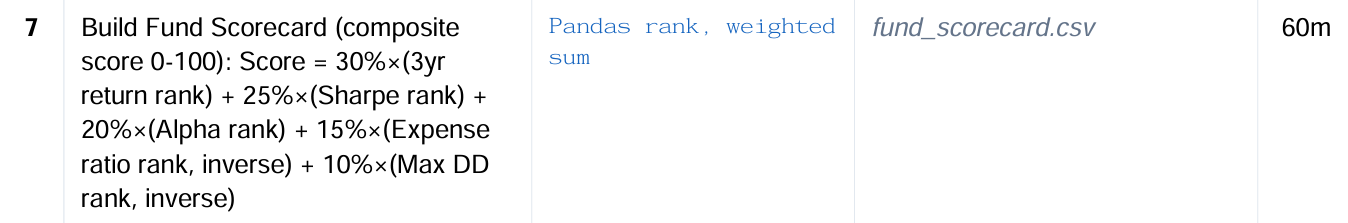

In [228]:
scorecard = cagr_df.merge(sharpe_df,on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df,on="amfi_code")
scorecard = scorecard.merge(max_dd_df,on="amfi_code")
scorecard = scorecard.merge(fund_df[["amfi_code","expense_ratio_pct"]],on="amfi_code")

In [229]:
scorecard["return_rank"] = (scorecard["3Y_CAGR"].rank(ascending=False))
scorecard["sharpe_rank"] = (scorecard["sharpe_ratio"].rank(ascending=False))
scorecard["alpha_rank"] = (scorecard["alpha"].rank(ascending=False))

In [230]:
scorecard["expense_rank"] = (scorecard["expense_ratio_pct"].rank(ascending=True))

In [231]:
scorecard["dd_rank"] = (scorecard["max_drawdown_pct"].abs().rank(ascending=True))

In [232]:
scorecard["score"] = (0.30 * scorecard["return_rank"]+ 0.25 * scorecard["sharpe_rank"]+ 0.20 * scorecard["alpha_rank"]+ 0.15 * scorecard["expense_rank"]+ 0.10 * scorecard["dd_rank"])

In [233]:
scorecard["score"] = (100*(scorecard["score"]-scorecard["score"].min())/(scorecard["score"].max()-scorecard["score"].min()))

In [234]:
scorecard = scorecard.sort_values("score",ascending=False)

In [235]:
scorecard.to_csv(REPORT_DIR/ "fund_scorecard.csv",index=False)

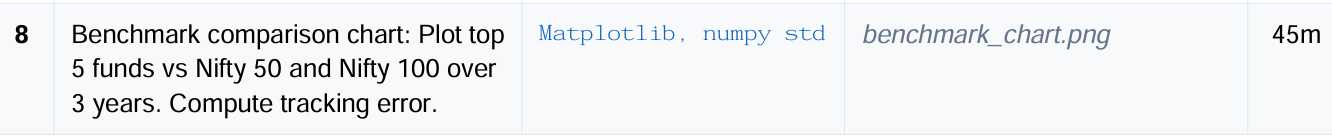

In [236]:
import matplotlib.pyplot as plt

In [237]:
top5 = scorecard.head(5)["amfi_code"].tolist()

In [238]:
nifty50 = benchmark_df[benchmark_df["index_name"] == "NIFTY50"].copy()

nifty100 = benchmark_df[benchmark_df["index_name"] == "NIFTY100"].copy()

nifty50["return"] = nifty50["close_value"].pct_change()
nifty100["return"] = nifty100["close_value"].pct_change()

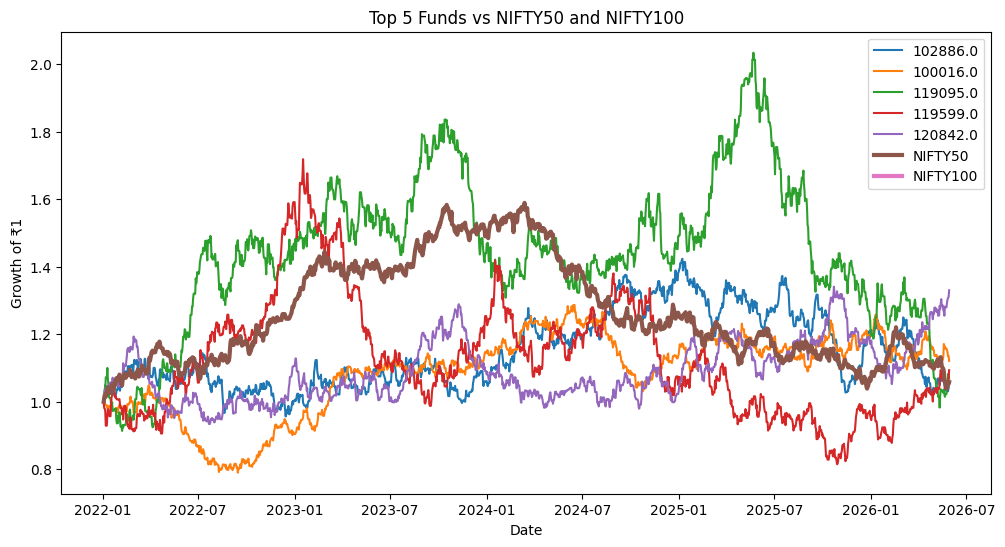

In [239]:
plt.figure(figsize=(12,6))

for code in top5:
    fund = nav_df[nav_df["amfi_code"] == code].copy()
    fund = fund.sort_values("date")
    fund["return"] = fund["nav"].pct_change()
    cumulative = (1 + fund["return"].fillna(0)).cumprod()
    plt.plot(fund["date"],cumulative,label=str(code))
    
plt.plot(nifty50["date"],(1 + nifty50["return"].fillna(0)).cumprod(),label="NIFTY50",linewidth=3)
plt.plot(nifty100["date"],(1 + nifty100["return"].fillna(0)).cumprod(),label="NIFTY100",linewidth=3)
plt.title("Top 5 Funds vs NIFTY50 and NIFTY100")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.savefig(REPORT_DIR/ "benchmark_chart.png")
plt.show()

In [240]:
tracking_result = []
for code in top5:
    fund = nav_df[nav_df["amfi_code"] == code]
    merged = pd.merge(fund,nifty50,on="date")
    merged["diff"] = (merged["daily_return"]-merged["return"])
    tracking_error = (merged["diff"].std()* np.sqrt(252))
    tracking_result.append([code, round(tracking_error,4)])
tracking_df = pd.DataFrame(tracking_result,columns=["amfi_code","tracking_error"])
print(tracking_df)

   amfi_code  tracking_error
0   102886.0          0.2269
1   100016.0          0.1964
2   119095.0          0.2810
3   119599.0          0.2803
4   120842.0          0.2204
